In [ ]:
import pandas as pd
import numpy as np
np.set_printoptions(legacy = "1.25")
import os
from pathlib import Path
import fitting_routines as fit
import plot_functions as plot
import warnings
warnings.filterwarnings("ignore") # none of the warnings break anything

#size = [0.2475,0.200,0.1650] # size of sightline FOV
size = [0.33]

COLUMNS = ["Latitude", "Long", "Mean Parallax", "Mean Parallax Error", "Parallax Dispersion", 
            "Number at parallax mean", "Clump 1 Parallax", "Clump 2 Parallax", "Clump 1 Parallax Sigma",
            "Clump 2 Parallax Sigma", "Number at Clump 1 Parallax Mean", "Number at Clump 2 Parallax Mean",
            "Mean Magnitude", "Magnitude Dispersion", "Number at Mag mean", 
            "Mean Color", "Color Dispersion", "Number at color mean", "Count", "Magnitude Distinctness", 
            "D1Mag Distinctness", "D2Mag Distinctness", "Double Clump width", "Color Distinctness", 
            "Distance Modulus", "Red Clump Fraction", "Red Clump Width", "Red Clump 1 Width",
            "Red Clump 2 Width"]

for s in size:
    TotalGood_Single = pd.DataFrame(columns=[COLUMNS])
    TotalGood_Double = pd.DataFrame(columns=[COLUMNS])
    TotalBad = pd.DataFrame(columns=[COLUMNS])

    b = np.arange(-6,5,s)
    Al = np.arange(-9.9,10,s)

    for i in b: # run functions for sightlines
        # find folder with csvs
        dir_name = f'Gaia_Data/b_{i:0.4f}_{s:0.4f}_degrees'
        os.makedirs(dir_name, exist_ok=True)
        path = Path(dir_name)

        #create folders and lists for plots
        plot_path = f'Plots/Diagnostics/b_{i:0.4f}_diagnostics_test_{s:0.4f}_degrees'
        os.makedirs(plot_path, exist_ok=True)
        plotpath = Path(plot_path)

        Good_Single = pd.DataFrame(columns=[COLUMNS])
        Good_Double = pd.DataFrame(columns=[COLUMNS])
        Bad = pd.DataFrame(columns=[COLUMNS])
        count = 0
        for l in Al:
            try:
                df = pd.read_csv(path / f'l_{l:0.4f}_b_{i:0.4f}.csv') # read in csv
                df["l"] = df["l"]-360
                #df = df.loc[(df["b"]<i)&(df["l"]<l)]
                redclump = fit.redclumpfinder_v1(df) # find the red clump
                zeropoint = fit.zeropoint(redclump)
                parallax = fit.parallax(redclump, zeropoint) # sigma clip parallax both before and after applying zero point correction
                doubleclump = fit.doubleclump_finder_v1(df, redclump)
                doubleparallax = fit.doublefinalfit(redclump, zeropoint)
                plot.DRedClumpPlot(redclump, parallax, df, doubleclump, doubleparallax, plotpath=plotpath, l=l, b=i, s=s)
                #print("Finished fitting", f'l_{l:0.4f}_b_{i:0.4f}_s_{s:0.4f}')
                count = count + 1
            except RuntimeError: # sometimes it will fail to fit due to the post-histogram selection and will crash
                try:
                    redclump = fit.redclumpfinder_v2(df) # see if it will fit if we change the spread for the first cut
                    zeropoint = fit.zeropoint(redclump)
                    parallax = fit.parallax(redclump, zeropoint)
                    doubleclump = fit.doubleclump_finder_v2(df, redclump)
                    doubleparallax = fit.doublefinalfit(redclump, zeropoint)
                    plot.DRedClumpPlot(redclump, parallax, df, doubleclump, doubleparallax, plotpath=plotpath, l=l, b=i, s=s)
                    #print("Finished fitting", f'l_{l:0.4f}_b_{i:0.4f}_s_{s:0.4f}')
                    count = count + 1
                except RuntimeError:
                    #print("Could not fit", f'l_{l:0.4f}_b_{i:0.4f}_s_{s:0.4f}') # if not, save the fitting cut and 2D histogram for troubleshooting
                    plot.DRedClumpPlot_runtime(redclump, df, plotpath=plotpath, l=l, b=i, s=s)
                    continue
                except KeyError: # usually means it could find a fit, but for some reason could not go beyond plotting the histograms
                    #print("Key Error for", f'l_{l:0.4f}_b_{i:0.4f}_s_{s:0.4f}')
                    plot.DRedClumpPlot_break(redclump, df, doubleclump, plotpath=plotpath, l=l, b=i, s=s)
                    continue
                except TypeError: # error with parameters, could not make a fit
                    #print("Type Error for:", f'l_{l:0.4f}_b_{i:0.4f}_s_{s:0.4f}')
                    plot.DRedClumpPlot_type(redclump, df, doubleclump, plotpath=plotpath, l=l, b=i, s=s)
                    continue
                except ValueError: # error with parameters, could not make a fit
                    plot.DRedClumpPlot_break(redclump, df, doubleclump, plotpath=plotpath, l=l, b=i, s=s)
                    #print("Value Error for:", f'l_{l:0.4f}_b_{i:0.4f}_s_{s:0.4f}')
                    continue
                except NameError:
                    plot.DRedClumpPlot_break(redclump, df, doubleclump, plotpath=plotpath, l=l, b=i, s=s)
                    #print("Value Error for:", f'l_{l:0.4f}_b_{i:0.4f}_s_{s:0.4f}')
                    continue
                continue
            except KeyError: # usually means it could find a fit, but for some reason could not go beyond plotting the histograms
                #print("Key Error for", f'l_{l:0.4f}_b_{i:0.4f}_s_{s:0.4f}')
                plot.DRedClumpPlot_break(redclump, df, doubleclump, plotpath=plotpath, l=l, b=i, s=s)
                continue
            except FileNotFoundError: # sometimes the data downloader cannot find a sightline along each latitude and so various
                                     # sightlines may, incosistently, not be available in a latitude
              #print("Could not find file", f'l_{l:0.4f}_b_{i:0.4f}')
              continue
            except TypeError: # error with parameters, could not make a fit
                #print("Type Error for:", f'l_{l:0.4f}_b_{i:0.4f}_s_{s:0.4f}')
                plot.DRedClumpPlot_type(redclump, df, doubleclump, plotpath=plotpath, l=l, b=i, s=s)
                continue
            except ValueError: # error with parameters, could not make a fit
                plot.DRedClumpPlot_break(redclump, df, doubleclump, plotpath=plotpath, l=l, b=i, s=s)
                #print("Value Error for:", f'l_{l:0.4f}_b_{i:0.4f}_s_{s:0.4f}')
                continue
            except NameError:
                plot.DRedClumpPlot_break(redclump, df, doubleclump, plotpath=plotpath, l=l, b=i, s=s)
                #print("Value Error for:", f'l_{l:0.4f}_b_{i:0.4f}_s_{s:0.4f}')
                continue

            # do not modify placement of these; concatenation needs to happen after all of the try/except loops or else
            # the columns can have different lengths causing an error when analyzing
            if redclump["Magnitude Distinctness"]>1 and redclump["Color Distinctness"]>1 and redclump["Red Clump Width"] < .45 and redclump["Red Clump Width"]>0.29 and np.abs(parallax["parallax sigma"])<0.3 and (doubleclump["peak difference"] > 0.65 or doubleclump["clump 1 distinctness"]<1 or doubleclump["clump 2 distinctness"]<1):
                fitcut = parallax["dataframe"]
                Good_Single = pd.concat([pd.DataFrame([[i, l, parallax["parallax peak"], parallax["mean error"], np.abs(parallax["parallax sigma"]),
                                                parallax["Number at parallax mean"], doubleparallax["parallax peak 1"],
                                                doubleparallax["parallax peak 2"], doubleparallax["parallax sigma 1"],
                                                doubleparallax["parallax sigma 2"], doubleparallax["Number at parallax mean 1"],
                                                doubleparallax["Number at parallax mean 2"], redclump["mag"], redclump["mag sigma"], 
                                                redclump["Number at mag mean"], redclump["color"], redclump["color sigma"], 
                                                redclump["Number at color mean"], len(fitcut["phot_g_mean_mag"]), 
                                                redclump["Magnitude Distinctness"], doubleclump["clump 1 distinctness"],
                                                doubleclump["clump 2 distinctness"], doubleclump["peak difference"], 
                                                redclump["Color Distinctness"], 5*np.log10(1/parallax["parallax peak"])-5, 
                                                redclump["Red Clump Fraction"], redclump["Red Clump Width"],
                                                doubleclump["Red Clump 1 Width"], doubleclump["Red Clump 2 Width"]]],
                                                columns=Good_Single.columns), Good_Single], ignore_index=True)
            
            if redclump["Magnitude Distinctness"]>1 and redclump["Color Distinctness"]>1 and redclump["Red Clump Width"] < .45 and redclump["Red Clump Width"]>0.29 and np.abs(parallax["parallax sigma"])<0.3 and doubleclump["peak difference"] < 0.65 and doubleclump["clump 1 distinctness"]>1 and doubleclump["clump 2 distinctness"]>1:
                fitcut = parallax["dataframe"]
                Good_Double = pd.concat([pd.DataFrame([[i, l, parallax["parallax peak"], parallax["mean error"], np.abs(parallax["parallax sigma"]),
                                                parallax["Number at parallax mean"], doubleparallax["parallax peak 1"],
                                                doubleparallax["parallax peak 2"], doubleparallax["parallax sigma 1"],
                                                doubleparallax["parallax sigma 2"], doubleparallax["Number at parallax mean 1"],
                                                doubleparallax["Number at parallax mean 2"], redclump["mag"], redclump["mag sigma"], 
                                                redclump["Number at mag mean"], redclump["color"], redclump["color sigma"], 
                                                redclump["Number at color mean"], len(fitcut["phot_g_mean_mag"]), 
                                                redclump["Magnitude Distinctness"], doubleclump["clump 1 distinctness"],
                                                doubleclump["clump 2 distinctness"], doubleclump["peak difference"], 
                                                redclump["Color Distinctness"], 5*np.log10(1/parallax["parallax peak"])-5, 
                                                redclump["Red Clump Fraction"], redclump["Red Clump Width"],
                                                doubleclump["Red Clump 1 Width"], doubleclump["Red Clump 2 Width"]]],
                                                columns=Good_Double.columns), Good_Double], ignore_index=True)

            else:
                Badfitcut = parallax["dataframe"]
                Bad = pd.concat([pd.DataFrame([[i, l, parallax["parallax peak"], parallax["mean error"], np.abs(parallax["parallax sigma"]),
                                                parallax["Number at parallax mean"], doubleparallax["parallax peak 1"],
                                                doubleparallax["parallax peak 2"], doubleparallax["parallax sigma 1"],
                                                doubleparallax["parallax sigma 2"], doubleparallax["Number at parallax mean 1"],
                                                doubleparallax["Number at parallax mean 2"], redclump["mag"], redclump["mag sigma"], 
                                                redclump["Number at mag mean"], redclump["color"], redclump["color sigma"], 
                                                redclump["Number at color mean"], len(Badfitcut["phot_g_mean_mag"]), 
                                                redclump["Magnitude Distinctness"], doubleclump["clump 1 distinctness"],
                                                doubleclump["clump 2 distinctness"], doubleclump["peak difference"], 
                                                redclump["Color Distinctness"], 5*np.log10(1/parallax["parallax peak"])-5, 
                                                redclump["Red Clump Fraction"], redclump["Red Clump Width"],
                                                doubleclump["Red Clump 1 Width"], doubleclump["Red Clump 2 Width"]]],
                                                columns=Bad.columns), Bad], ignore_index=True)
            
        Good_Single.to_csv(path / f"b_{i:0.4f}_s_{s:0.4f}_good_single_cuts.csv") # save all cuts along a latitude to a csv so you can add missed bad sightlines 
                                                        # to bad csv
        Good_Double.to_csv(path / f"b_{i:0.4f}_s_{s:0.4f}_good_double_cuts.csv")
        Bad.to_csv(path / f"b_{i:0.4f}_s_{s:0.4f}_bad_cuts.csv")

        TotalGood_Single = pd.concat([TotalGood_Single,Good_Single], ignore_index=True)
        TotalGood_Double = pd.concat([TotalGood_Double,Good_Double], ignore_index=True)
        TotalBad  = pd.concat([TotalBad,Bad], ignore_index=True)

        try:
            plot_path2 = f'Plots/mean plots'
            os.makedirs(plot_path2, exist_ok=True)
            plotpath2 = Path(plot_path2)
            meanplot = pd.read_csv(path / f"b_{i:0.4f}_s_{s:0.4f}_good_single_cuts.csv")
            plot.Dmeanplot(meanplot, Al=Al, b=i, plotpath=plotpath2, s=s)
            #print("Finished", f'{i:0.4f}')
        except:
            print(f"nothing to plot for (b = {i:0.4f}, s = {s:0.4f}")
            continue
    TotalGood_Single
    TotalGood_Double
    TotalBad
    TotalGood_Single.to_csv(f'Gaia_Data/Total_Good_Single_Fits_s_{s:0.4f}')
    TotalGood_Double.to_csv(f'Gaia_Data/Total_Good_Double_Fits_s_{s:0.4f}')
    TotalBad.to_csv(f'Gaia_Data/Total_Bad_Fits_s_{s:0.4f}')
    plot_path3 = f'Plots'
    os.makedirs(plot_path3, exist_ok=True)
    plotpath3 = Path(plot_path3)
    plot.Dtotalplot(TotalGood_Single,plotpath=plotpath3, s=s)
    print(f"Percent bad sightlines for sightline size {s:0.4f}:", len(TotalBad["Mean Parallax"])/(len(b)*len(Al))*100, "%")

In [9]:
Bad

,Latitude,Long,Mean Parallax,Mean Parallax Error,Parallax Dispersion,Number at parallax mean,Clump 1 Parallax,Clump 2 Parallax,Clump 1 Parallax Sigma,Clump 2 Parallax Sigma,...,Magnitude Distinctness,D1Mag Distinctness,D2Mag Distinctness,Double Clump width,Color Distinctness,Distance Modulus,Red Clump Fraction,Red Clump Width,Red Clump 1 Width,Red Clump 2 Width


(array([   6.,    5.,   26.,   93.,  366.,  748., 2092., 2402., 2832.,
        1724.]),
 array([10.616683, 11.598939, 12.581195, 13.563451, 14.545707, 15.527963,
        16.510219, 17.492475, 18.474731, 19.456987, 20.439243]),
 <BarContainer object of 10 artists>)

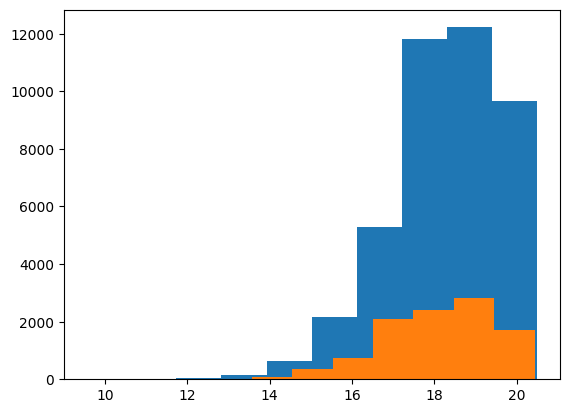

In [11]:
import matplotlib.pyplot as plt
l,i = -2.31,-3.03
dir_name = f'Gaia_Data/b_{i:0.2f}_0.3300_degrees'
os.makedirs(dir_name, exist_ok=True)
path = Path(dir_name)
df = pd.read_csv(path / f'l_{l:0.4f}_b_{i:0.4f}.csv') # read in csv
plt.hist(df["phot_g_mean_mag"])
df["l"] = df["l"]-360
df = df.loc[(df["b"]<i)&(df["l"]<l)]
plt.hist(df["phot_g_mean_mag"])

(0.0, 4.0)

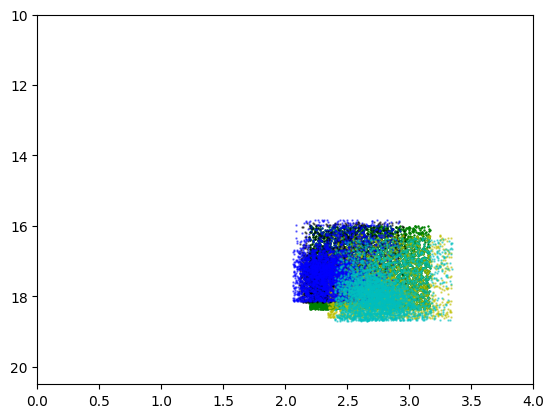

In [27]:
import matplotlib.pyplot as plt
import os
from pathlib import Path
import pandas as pd
l,i = -2.31,-3.03
dir_name = f'Gaia_Data/b_{i:0.2f}_0.3300_degrees'
os.makedirs(dir_name, exist_ok=True)
path = Path(dir_name)
df = pd.read_csv(path / f'l_{l:0.4f}_b_{i:0.4f}.csv') # read in csv
df["l"] = df["l"]-360
xrc,yrc,sxrc,syrc = fit.findrc(df)
tclump = fit.extractrc_v1(df,xrc,yrc,sxrc,syrc)
plt.scatter(tclump["bp_rp"],tclump["phot_g_mean_mag"], s = 0.55, c= 'g', alpha = 1, label = 'total')

df1 = df.loc[(df["b"]<i)&(df["l"]<l)]
xrc1,yrc1,sxrc1,syrc1 = fit.findrc(df1)
llclump = fit.extractrc_v1(df1,xrc1,yrc1,sxrc1,syrc1)
plt.scatter(llclump["bp_rp"],llclump["phot_g_mean_mag"], s = 0.55, c= 'k', alpha = 0.5, label = 'lower left quadrant')

df2 = df.loc[(df["b"]>i)&(df["l"]<l)]
xrc2,yrc2,sxrc2,syrc2 = fit.findrc(df2)
ulclump = fit.extractrc_v1(df2,xrc2,yrc2,sxrc2,syrc2)
plt.scatter(ulclump["bp_rp"],ulclump["phot_g_mean_mag"], s = 0.55, c= 'y', alpha = 0.5, label = 'upper left quadrant')

df3 = df.loc[(df["b"]<i)&(df["l"]>l)]
xrc3,yrc3,sxrc3,syrc3 = fit.findrc(df3)
lrclump = fit.extractrc_v1(df3,xrc3,yrc3,sxrc3,syrc3)
plt.scatter(lrclump["bp_rp"],lrclump["phot_g_mean_mag"], s = 0.55, c= 'b', alpha = 0.5, label = 'lower right quadrant')

df4 = df.loc[(df["b"]>i)&(df["l"]>l)]
xrc4,yrc4,sxrc4,syrc4 = fit.findrc(df4)
urclump = fit.extractrc_v1(df4,xrc4,yrc4,sxrc4,syrc4)
plt.scatter(urclump["bp_rp"],urclump["phot_g_mean_mag"], s = 0.55, c= 'c', alpha = 0.5, label = 'upper right quadrant')

plt.ylim(20.5,10)
plt.xlim(0,4)

3456 3364


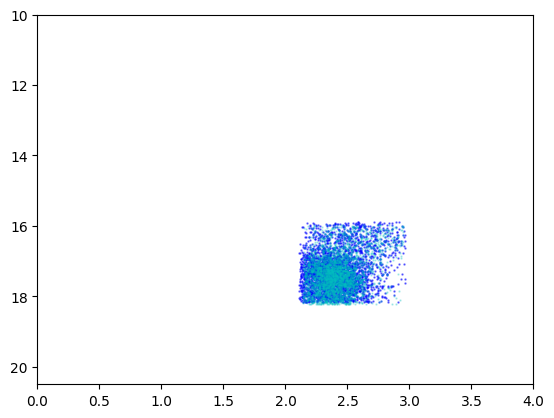

In [33]:
l,i = -2.31,-3.03
dir1_name = f'Gaia_Data/b_{i:0.2f}_0.3300_degrees'
os.makedirs(dir1_name, exist_ok=True)
path1 = Path(dir1_name)
df1 = pd.read_csv(path1 / f'l_{l:0.4f}_b_{i:0.4f}.csv') # read in csv
df1["l"] = df1["l"]-360
df1 = df1.loc[(df1["b"]<i)&(df1["l"]<l)]
xrc1,yrc1,sxrc1,syrc1 = fit.findrc(df1)
llclump = fit.extractrc_v1(df1,xrc1,yrc1,sxrc1,syrc1)
plt.scatter(llclump["bp_rp"],llclump["phot_g_mean_mag"], s = 0.55, c= 'b', alpha = 0.5, label = 'lower left quadrant')

L,I = (-2.31-0.165),(-3.03-0.165)
dir2_name = f'Gaia_Data/b_{I:0.2f}_0.1650_degrees'
os.makedirs(dir2_name, exist_ok=True)
path2 = Path(dir2_name)
df2 = pd.read_csv(path2 / f'l_{L:0.4f}_b_{I:0.4f}.csv') # read in csv
df2["l"] = df2["l"]-360
df2 = df2.loc[(df2["b"]<i)&(df2["l"]<l)]
xrc2,yrc2,sxrc2,syrc2 = fit.findrc(df2)
sclump = fit.extractrc_v1(df2,xrc2,yrc2,sxrc2,syrc2)
plt.scatter(sclump["bp_rp"],sclump["phot_g_mean_mag"], s = 0.55, c= 'c', alpha = 0.25, label = 'smaller search')
plt.ylim(20.5,10)
plt.xlim(0,4)

print(len(sclump["phot_g_mean_mag"]),len(llclump["phot_g_mean_mag"]))

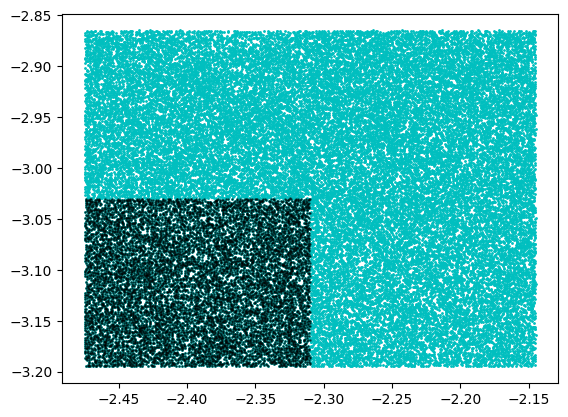

In [17]:
import matplotlib.pyplot as plt
l,i = -2.31,-3.03
dir_name = f'Gaia_Data/b_{i:0.2f}_0.3300_degrees'
os.makedirs(dir_name, exist_ok=True)
path = Path(dir_name)
df = pd.read_csv(path / f'l_{l:0.4f}_b_{i:0.4f}.csv') # read in csv
df["l"] = df["l"]-360
plt.scatter(df["l"],df["b"], s= 1, c='c',alpha = 1)
df = df.loc[(df["b"]<i)&(df["l"]<l)]
plt.scatter(df["l"],df["b"], s = 0.75, c= 'k', alpha = 0.5)

Text(0, 0.5, 'Bar Angle')

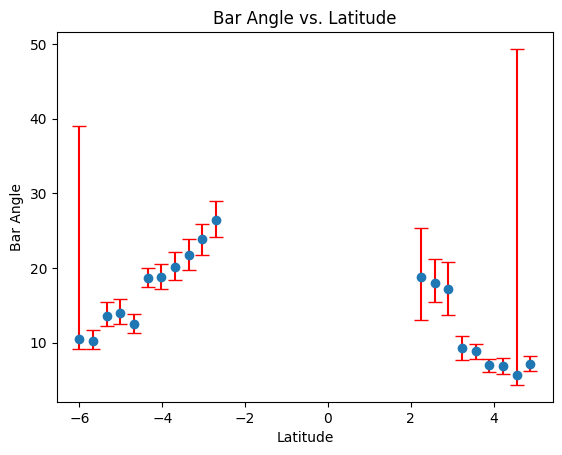

In [1]:
import matplotlib.pyplot as plt
b = [-6.00 , -5.67, -5.34, -5.01, -4.68, -4.35,-4.02, -3.69, -3.36, -3.03, -2.7, 2.25, 2.58, 2.91, 3.24, 3.57, 3.9 , 4.23, 4.56, 4.89]
alpha = [10.46, 10.3, 13.62, 14.05, 12.54, 18.68, 18.74, 20.15, 21.74, 23.86, 26.47, 18.75, 17.98, 17.16, 9.26, 8.84, 7.05, 6.83, 5.69, 
        7.20]
err_upper = [28.62, 1.42, 1.78, 1.84, 1.26, 1.38, 1.81, 1.97, 2.21, 2.08, 2.55, 6.56, 3.19, 3.60, 1.66, 0.99, 0.82, 1.12, 43.64, 1.03]
err_lower = [1.32, 1.15, 1.37, 1.5, 1.24, 1.22, 1.55, 1.76, 2.02, 2.05, 2.30, 5.66, 2.55, 3.41, 1.59, 0.98, 0.93, 1.01, 1.33, 0.97]

plt.errorbar(
    b, alpha,
    yerr=[err_lower, err_upper],  # tuple: (lower, upper)
    fmt='o',                        # marker style
    ecolor='red',                   # error bar color
    capsize=5,                      # cap length in points
    elinewidth=1.5,                 # error bar line width
    markersize=6)
plt.title("Bar Angle vs. Latitude")
plt.xlabel("Latitude")
plt.ylabel("Bar Angle")

In [12]:
b_values = np.arange(-6, 5, 0.33)

for i in b_values:
    if i > -2.2 and i < 2.1:
        index = np.where(b_values==i)
        b_values = np.delete(b_values, index)

b_values

array([-6.  , -5.67, -5.34, -5.01, -4.68, -4.35, -4.02, -3.69, -3.36,
       -3.03, -2.7 , -2.37,  2.25,  2.58,  2.91,  3.24,  3.57,  3.9 ,
        4.23,  4.56,  4.89])